In [1]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from plotting import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

3.9.2


In [2]:
def find_nearest(obj1, obj2):
    #### get dRs
    dR = obj1.deltaR(obj2)
    #### mask where dR to self
    dR = ak.where(dR == 0, None, dR)
    idx = ak.argmin(dR, axis=-1)
    nearest_other = obj2[idx]
    return nearest_other

In [3]:
def sigmoid(x ,L, x0, k):
    y = L / (1 + np.exp(-k*(x-x0)))
    return (y)
def get_fracs(radii, weights, weights_orig):
    fracs = []
    for R, weight in zip(radii, weights):
        # print("orig neg weights ", ak.sum(weights<0))
        # print("n orig weights ", len(weights))
        # print("Frac orgi negative weights ", ak.sum(weights_orig<0)/len(weights))
        frac = (1-ak.sum(weight<0)/ak.sum(weights_orig<0))
        fracs.append(round(frac, 2))
    return fracs
def fit_sigmoid(radii, frac, des_frac=25, string=""):
    print(frac)
    ###initial guess
    if frac[0]>1.:
        frac.insert(0, 0)
        radii.insert(0,0)
    p0 = [max(frac), np.median(np.array(radii)),1]
    popt, pcov = curve_fit(sigmoid, np.array(radii), frac, p0)
    L, x0, k = popt
    if (L/(des_frac-k))-1 > 0:
        x = x0-((1/k)*np.log((L/(des_frac))-1))
        print(f"{string} x value where y = {des_frac}: {x}")
    else:
        print(f"No real solution for y = {des_frac} with sigmoid fit.")
    return popt, pcov
# def plot_cellradius_comp():
def sigmoid_Lfixed(x, x0, k, L=100.0):
    # clip exponent to avoid overflow warnings
    z = np.clip(-k*(x-x0), -700, 700)
    return L / (1.0 + np.exp(z))
def fit_sigmoid_fixedL(radii, fracs, L=100.0, des_frac=25):
    # initial guesses
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
    p0 = [np.median(np.array(radii)),1]

    # bounds: x0 within radii range (with padding), k positive
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = ([np.min(radii) - pad, 1e-6], [np.max(radii) + pad, 10.0])

    popt, pcov = curve_fit(lambda x, x0, k: sigmoid_Lfixed(x, x0, k, L=L),
                           radii, fracs, p0=p0, bounds=bounds)

    x0, k = popt
    return (L, x0, k), pcov
def richards(x, x0, k, nu, L=1.0):
    z = -k*(x-x0)
    return L / (1.0 + np.exp(z))**(1.0/nu)
def fit_richards(radii, fracs, L=1.0):
    x0_guess = np.median(radii)
    k_guess  = 2/np.median(radii)
    nu_guess = 1.0
        # optional: let L float, or fix it to max observed
    if L is None:
        L = fracs.max()
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
   
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = (
        [np.min(radii)-pad, 1e-3, 0.05],   # x0, k, nu
        [np.max(radii)+pad, 10.0/np.median(radii), 20.0]
    )

    popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),
                           radii, fracs, p0=[x0_guess, k_guess, nu_guess], bounds=bounds)
    return (*popt, L), pcov
def richards_x_at_y(y, x0, k, nu, L):
    y = float(y)
    if not (0.0 < y < L) or k == 0 or nu <= 0:
        return np.nan
    arg = (L / y)**nu - 1.0
    if arg <= 0:
        return np.nan
    return x0 - (1.0 / k) * np.log(arg)

In [4]:
def make_df(radii, weights_orig, inputpath0, inputpath1 = "gev_bigR.npy"):
    weights = []
    for R in radii:
        str_R = str(R).replace(".", "p")
        weights.append(np.load(inputpath0+str_R+inputpath1))
    fracs = get_fracs(radii, weights, weights_orig)
    df = pd.DataFrame({
        "radius": radii,
        "fraction": fracs,
        "weights": weights
    })
    return df
    

In [5]:
##### Load different cell radii -- all hard scatter RW's
ttbar_jets = ak.from_parquet('/oscar/data/mleblan6/lhay/ttbar_NLO_100k_alljetsV1.parquet')
order = ak.argsort(ttbar_jets.pt, axis=1, ascending=False)
jets = ttbar_jets[order]

#### load original weights for ttbar, z+jet
N=10000
weights_orig_10k = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy')[N:2*N]
weights_orig_z = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy")
weights_orig_ttbar = np.load("/oscar/data/mleblan6/lhay/ttbar_100k/ttbar_weight_100k.npy")

#### making the ttbar hp dataframes
radii_hp = [5,15,17,18.5,20,22,25,30,100]
ttbar_hp_df = make_df(radii_hp, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_hp_100k/100k_hp_emd_reweight_")
#### print the available fractions
print(ttbar_hp_df["fraction"].values)
#### if you would like to look up by fraction
df_f = ttbar_hp_df.set_index("fraction")
w_f = df_f.loc[0.71, "weights"]

#### make rest of ttbar dataframes

radii_ps = [1, 15, 18, 24, 25, 30, 50, 100]
ttbar_ps_df = make_df(radii_ps, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_ps_100k/100k_ps_emd_reweight_", "gev_ttbar.npy")

radii_had = [1, 18, 25, 28, 30, 50, 100]
ttbar_had_df = make_df(radii_had, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_had_100k/100k_had_emd_reweight_", "gev_ttbar.npy")

radii_had_10k = [1, 21, 25, 28, 30, 50]
ttbar_had_10k_df = make_df(radii_had_10k, weights_orig_ttbar[0:10000], "/oscar/data/mleblan6/lhay/reweighted_files/10k_ttbar_had/10k_had_emd_reweight_", "gev_ttbar.npy")

###### Camille hard process SEMD RW's
radii_cm_SEMD = [10, 25, 35, 40, 45, 47, 50, 55, 65, 75, 100]
zjet_SEMD_cm = make_df(radii_cm_SEMD, weights_orig_z, "/oscar/data/mleblan6/cell_resampling/SEMD_reweightings/rw_", ".npy")
##### Rishabh SEMD RW's w/ p=1
radii_hp = np.logspace(-5,-2,50)
hp_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hardprocess_reweights.npy")
fracs = get_fracs(radii_hp, hp_rw, weights_orig_z)
print(hp_rw.shape)
print(radii_hp.shape)
zjet_SEMD_hp_df = pd.DataFrame({"radius": radii_hp, "fraction": fracs, "weights": hp_rw.tolist()})

radii_ps =  np.logspace(-4,-2,50)
ps_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/showered_reweights.npy")
fracs = get_fracs(radii_ps, ps_rw, weights_orig_z)
zjet_SEMD_ps_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": ps_rw.tolist()})

had_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hadronization_reweights.npy")
fracs = get_fracs(radii_ps, had_rw, weights_orig_z)
zjet_SEMD_had_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": had_rw.tolist()})

#### RIshabh beta=0
radii_b0 = np.logspace(1,2.4,50)
b0_hp_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hardprocess_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_hp_rw, weights_orig_z)
zjet_b0_hp_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_hp_rw.tolist()})

b0_ps_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hardprocess_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_ps_rw, weights_orig_z)
zjet_b0_ps_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_ps_rw.tolist()})

b0_had_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hardprocess_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_had_rw, weights_orig_z)
zjet_b0_had_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_had_rw.tolist()})

#### beta=0
radii_b0 = np.logspace(1,2.4,50)
b0_hp_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hardprocess_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_hp_rw, weights_orig_z)
zjet_b0_hp_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_hp_rw.tolist()})

b0_ps_rw = np.load("/oscar/data/mleblan6/rjain/beta0/showered_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_ps_rw, weights_orig_z)
zjet_b0_ps_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_ps_rw.tolist()})

b0_had_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hadronization_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_had_rw, weights_orig_z)
zjet_b0_had_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_had_rw.tolist()})

#### beta=infinity
radii_binf = np.logspace(-4,-1,50)
binf_hp_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hardprocess_reweights.npy")
fracs = get_fracs(radii_binf, binf_hp_rw, weights_orig_z)
zjet_b0_hp_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_hp_rw.tolist()})

binf_ps_rw = np.load("/oscar/data/mleblan6/rjain/betainf/showered_reweights.npy")
fracs = get_fracs(radii_binf, binf_ps_rw, weights_orig_z)
zjet_binf_ps_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_ps_rw.tolist()})

binf_had_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hadronization_reweights.npy")
fracs = get_fracs(radii_binf, binf_had_rw, weights_orig_z)
zjet_binf_had_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_had_rw.tolist()})



#### z+2jet beta=2 dataframes

radii_beta2_hp_100k = [1.03,1.3,1.15,1.41,1.02,1.75,1.5,1.04]
radii_beta2_hp_100k.sort()
zjet_b2_hp_df = make_df(radii_beta2_hp_100k, weights_orig_z, "/oscar/data/mleblan6/jmarrinan/hp_reweights/100k_hp_emd_reweight_", "gev_Rmax_beta2.npy")

radii_beta2_ps_100k = [1,1.1,1.15,1.2,1.3,1.4,1.5,1.6,1.8,5]
zjet_b2_ps_df = make_df(radii_beta2_ps_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2/100k_ps_emd_b2_reweight_", "gev.npy")

radii_beta2_had_100k = [1.13,1.3,1.5,] #[1,1.1,1.13,1.15,1.2,1.3,1.4,1.5,1.6,1.8,2,3]
zjet_b2_had_df = make_df(radii_beta2_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2/100k_had_emd_b2_reweight_", "gev.npy")

radii_beta2NEW_ps_100k = [1,2,3,4, 10, 100]
zjet_ps_b2NEW_df = make_df(radii_beta2NEW_ps_100k, weights_orig_z, "/users/lhay/cres-distance/cell_reweighting_scripts/100k_ps_emd_b2NEW_reweight_", "gev.npy", )

[0.   0.07 0.17 0.25 0.37 0.53 0.71 0.87 1.  ]
(50, 100000)
(50,)


In [6]:
#### make z+jet dfs
radii_z = [5, 7, 10, 12, 15, 18, 20, 25]
zjet_hp_df = make_df(radii_z, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_hp_emd_reweight_")

radii_10k = [5, 7, 10, 12, 15, 18, 20, 25, 30, 150]
zjet_hp_10k_df = make_df(radii_10k, weights_orig_10k, "/oscar/data/mleblan6/rjain/trial1/hp_reweight_0to10k_", "GeV.npy")

radii_z = [5, 9, 10, 12.5, 12.6, 15, 17.2, 20, 25]
zjet_ps_df = make_df(radii_z, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_sho_emd_reweight_", "gev_bigR.npy")
radii_z = [5, 10, 13, 15, 17.2, 20, 25]
zjet_had_df = make_df(radii_z, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_had_emd_reweight_", "gev_bigR.npy")

[0.08 0.18 0.24 0.31 0.46 0.6  0.7  0.78 0.87 1.  ] [1.   1.1  1.15 1.2  1.3  1.4  1.5  1.6  1.8  5.  ]
Z+jets ps beta=2 100k R for 0.50 RW  1.559
[0.25 0.54 0.76] [1.13 1.3  1.5 ]
Z+jets had beta=2 100k R for 0.50 RW  1.478
[0.26 0.28 0.29 0.46 0.66 0.76 0.82 0.91] [1.02 1.03 1.04 1.15 1.3  1.41 1.5  1.75]
Z+jets hp beta=2 100k R for 0.50 RW  1.402


/tmp/ipykernel_3896472/1845725858.py:69: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),


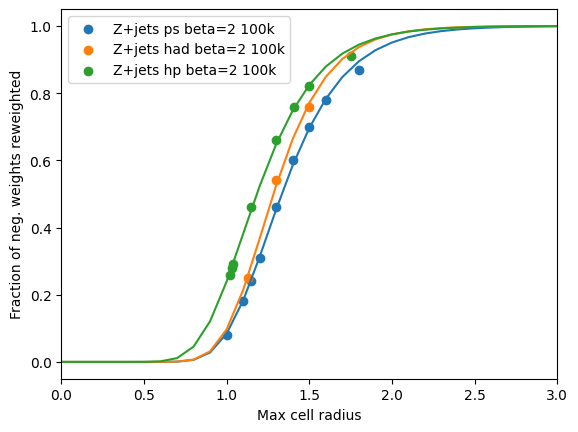

In [7]:
strings = ["Z+jets ps beta=2 100k", "Z+jets had beta=2 100k", "Z+jets hp beta=2 100k"]
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_b2_ps_df, zjet_b2_had_df, zjet_b2_hp_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.arange(-20,np.max(radii)+50)/10
    print(f"{strings[i]} R for 0.50 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.xlim(0, 3)
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

[0.01 0.01 0.02 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.12 0.13
 0.15 0.16 0.18 0.2  0.22 0.25 0.28 0.32 0.36 0.4  0.45 0.49 0.54 0.58
 0.62 0.66 0.69 0.73 0.76 0.78 0.81 0.83 0.85 0.87 0.89 0.9  0.91 0.92
 0.93 0.94 0.95 0.96 0.96 0.97 0.97 0.98] [0.0001     0.00010985 0.00012068 0.00013257 0.00014563 0.00015999
 0.00017575 0.00019307 0.0002121  0.000233   0.00025595 0.00028118
 0.00030888 0.00033932 0.00037276 0.00040949 0.00044984 0.00049417
 0.00054287 0.00059636 0.00065513 0.00071969 0.0007906  0.00086851
 0.0009541  0.00104811 0.0011514  0.00126486 0.0013895  0.00152642
 0.00167683 0.00184207 0.00202359 0.002223   0.00244205 0.0026827
 0.00294705 0.00323746 0.00355648 0.00390694 0.00429193 0.00471487
 0.00517947 0.00568987 0.00625055 0.00686649 0.00754312 0.00828643
 0.00910298 0.01      ]
Z+jets ps p=1 SEMD 100k R for 0.50 RW  0.002
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.01
 0.01 0.02 0.03 0.05 0.07 0.1  0.15 0.2  0.25 0.31 0.37 0.43 0.48 0.54

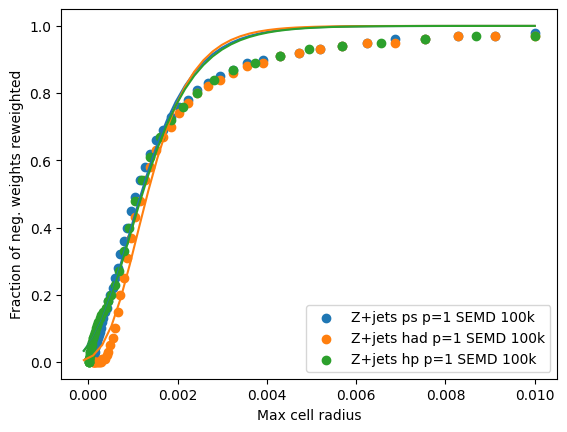

In [8]:
strings = ["Z+jets ps p=1 SEMD 100k", "Z+jets had p=1 SEMD 100k", "Z+jets hp p=1 SEMD 100k"]
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_SEMD_ps_df, zjet_SEMD_had_df, zjet_SEMD_hp_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.linspace(-0.0001, 0.01, 50)
    print(f"{strings[i]} R for 0.50 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01
 0.01 0.02 0.03 0.04 0.07 0.1  0.16 0.23 0.32 0.41 0.5  0.58 0.66 0.72
 0.77 0.82 0.86 0.89 0.91 0.93 0.95 0.96 0.97 0.98 0.98 0.99 0.99 0.99
 0.99 1.   1.   1.   1.   1.   1.   1.  ] [ 10.          10.68000433  11.40624924  12.18187912  13.01025217
  13.89495494  14.83981789  15.84893192  16.92666615  18.07768677
  19.30697729  20.6198601   22.0220195   23.51952635  25.11886432
  26.82695795  28.6512027   30.59949687  32.68027589  34.90254879
  37.2759372   39.81071706  42.51786303  45.40909611  48.49693429
  51.79474679  55.31681198  59.07837912  63.09573445  67.38627168
  71.9685673   76.862461    82.0891416   87.67123873  93.63292088
 100.         106.80004325 114.06249239 121.8187912  130.10252169
 138.94954944 148.3981789  158.48931925 169.2666615  180.7768677
 193.06977289 206.19860095 220.220195   235.19526351 251.18864315]
Z+jets $\beta=0$ Hadronization R for 0.50 RW  61.159
[0.   0.26 0.55 0.68 0.77 0.85 0

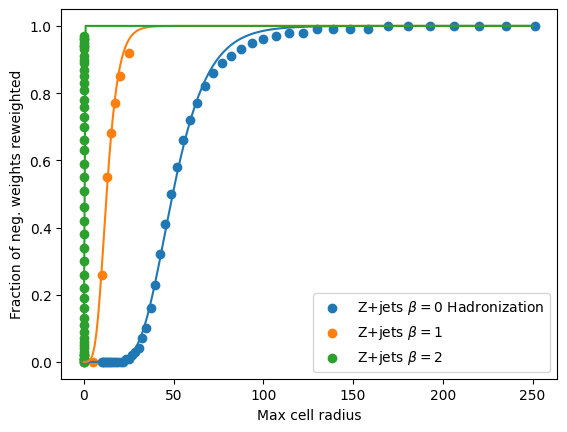

In [9]:
strings = [r"Z+jets $\beta=0$ Hadronization", r"Z+jets $\beta=1$", r"Z+jets $\beta=2$"]
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_b0_had_df, zjet_had_df, zjet_binf_had_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.linspace(-0.0001, 250, 251)
    print(f"{strings[i]} R for 0.50 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

TTbar hp 100k R for 0.75 RW  25.968
TTBar ps 100k R for 0.75 RW  35.951
TTBar had 100k R for 0.75 RW  35.208
Z+jets hp 100k R for 0.75 RW  12.569
Z+jets hp 10k R for 0.75 RW  15.898
TTbar had 10k R for 0.75 RW  41.389


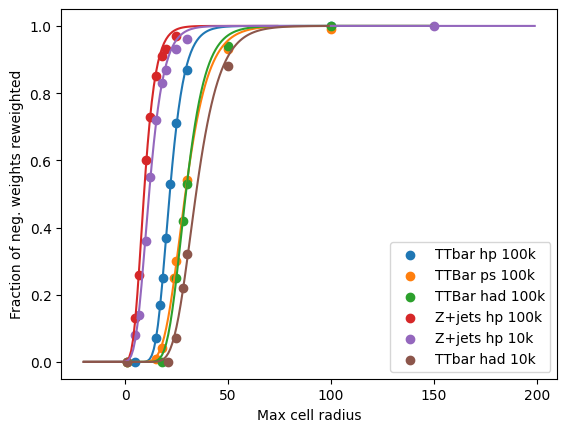

In [10]:
fracs = []
strings = ["TTbar hp 100k", "TTBar ps 100k", "TTBar had 100k","Z+jets hp 100k",  'Z+jets hp 10k', "TTbar had 10k"]
weights_orig_list = [weights_orig_ttbar, weights_orig_ttbar, weights_orig_ttbar, weights_orig_z,  weights_orig_10k, weights_orig_ttbar[0:10000]]
rw_dicts = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df, zjet_hp_df,  zjet_hp_10k_df, ttbar_had_10k_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.arange(-20,np.max(radii)+50)
    print(f"{strings[i]} R for 0.75 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")

plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

In [11]:
def plot_diff_rw(obs, dfs, strings, fracs, weights_orig, xmin, xmax, nbins, obs_str = "", sel=None, title=""):
    if sel is None:
        sel  = np.ones_like(weights_orig, dtype=bool)
    fig, (ax, rax) = plt.subplots(nrows=2,
                        ncols=1,
                        figsize=(8,6),
                        gridspec_kw={"height_ratios": (3, 1)},
                        sharex=True)
    h_orig = hist.Hist(
        hist.axis.Regular(nbins,xmin, xmax,name="data",label="orig",),
        storage=hist.storage.Weight(), )
    h_orig.fill(obs, weight = weights_orig[sel])
    h_orig = h_orig/h_orig.sum(flow=False).value
    for i, df in enumerate(dfs):
        weights = np.array(df.loc[df["fraction"]==fracs[i], "weights"].squeeze())[sel]
        h = hist.Hist(
            hist.axis.Regular(nbins,xmin, xmax,name="data",label="reweighted",),
            storage=hist.storage.Weight(), 
        )
        h.fill(obs, weight = weights)
        #### Normalize hists
        h = h/h.sum(flow=False).value
        bin_centers = h.axes[0].centers
        bin_edges = h.axes[0].edges
        ratio, ratio_unc = get_ratio_unc(h, h_orig)
        ratio1, ratio_unc1 = get_ratio_unc(h_orig, h_orig)
        hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black')
        hep.histplot(ratio, bins=bin_edges, ax=rax,  color=cmap[i], histtype='step') #yerr = np.sqrt(ratio_unc),
        hep.histplot(h, ax=ax, label = f"{round(fracs[i]*100)}% RW {strings[i]}", color=cmap[i], histtype='step')
        
    hep.histplot(h_orig, ax=ax, label = "Original", color='black')
    rax.set_xlabel(rf"${quantity}$")
    rax.set_ylabel("Reweight/Orig")
    ax.set_title(title)
    ax.set_ylabel(rf"d$\sigma/d{quantity}$")
    ax.set_xlabel(None)
    rax.set_ylim(0.85, 1.15)
    ax.legend()
    ax.set_yscale('log')
    plt.subplots_adjust(hspace=0.05)
    plt.savefig(f"../plots/ttbar_100k/comp_frac_{round(fracs[0], 0)}_{obs_str[0]}.png")
    plt.show()

In [12]:
def plot_same_rw_all(obs, df, weights_orig, numbins, xmin, xmax, obs_str = "", sel=None, ymin=1e-4, ymax=1e0, logy=True, title="TTbar"):
    if sel is None:
        sel  = np.ones_like(weights_orig, dtype=bool)
    sel_weights = weights_orig[sel]
    cmap  = cm.tab10.colors 
    fig, (ax, rax) = plt.subplots(nrows=2,
                            ncols=1,
                            figsize=(8,6),
                            gridspec_kw={"height_ratios": (3, 1)},
                            sharex=True)

    
    h_orig = hist.Hist(
            hist.axis.Regular(numbins,xmin, xmax,name="data",label="TTbar orig",),
            storage=hist.storage.Weight(), 
        )
    h_orig.fill(obs, weight = sel_weights)
    h_orig = h_orig/h_orig.sum(flow=False).value
    for i, R in enumerate(df["radius"].values):
        weights = df.loc[df["radius"]==R, "weights"].iloc[0][sel]
        frac = df.loc[df["radius"]==R, "fraction"].iloc[0]
        h = hist.Hist(
            hist.axis.Regular(numbins,xmin, xmax,name="data",label="TTbar reweighted",),
            storage=hist.storage.Weight(), 
        )
        h.fill(obs, weight = weights)
        #### Normalize hists
        h = h/h.sum(flow=False).value
        bin_centers = h.axes[0].centers
        bin_edges = h.axes[0].edges
        ratio, ratio_unc = get_ratio_unc(h, h_orig)
        ratio1, ratio_unc1 = get_ratio_unc(h_orig, h_orig)
        hep.histplot(ratio, bins=bin_edges, ax=rax,  color=cmap[i], histtype='step') #yerr = np.sqrt(ratio_unc),
        hep.histplot(h, ax=ax, label = f"{round(frac*100)}% RW (R={R} GeV)", color=cmap[i])
    hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black')
    hep.histplot(h_orig, ax=ax, label = "Original", color='black')
    rax.set_xlabel(rf"${obs_str}$")
    rax.set_ylabel("Reweight/Orig")
    ax.set_title(title)
    ax.set_ylabel(rf"d$\sigma/d{obs_str}$")
    ax.set_xlabel(None)
    rax.set_ylim(0.85, 1.15)
    rax.set_xlim(xmin, xmax)
    if logy:
        ax.set_yscale('log')
    ax.set_ylim(ymin, ymax)
    
    ax.legend()
    plt.subplots_adjust(hspace=0.05)
    plt.savefig(f"../plots/ttbar_100k/comp_{title}_{quantity[0]}.png")
    plt.show()

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01
 0.01 0.02 0.03 0.04 0.07 0.1  0.16 0.23 0.32 0.41 0.5  0.58 0.66 0.72
 0.77 0.82 0.86 0.89 0.91 0.93 0.95 0.96 0.97 0.98 0.98 0.99 0.99 0.99
 0.99 1.   1.   1.   1.   1.   1.   1.  ]
[0.   0.26 0.55 0.68 0.77 0.85 0.92]
[0.25 0.54 0.76]


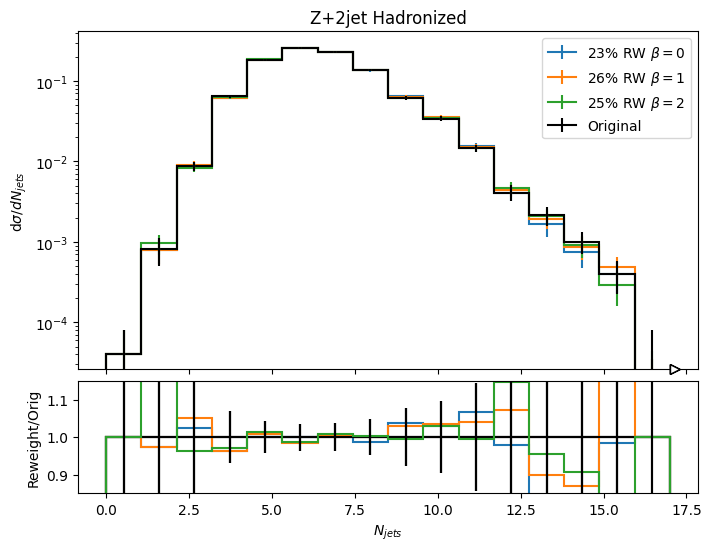

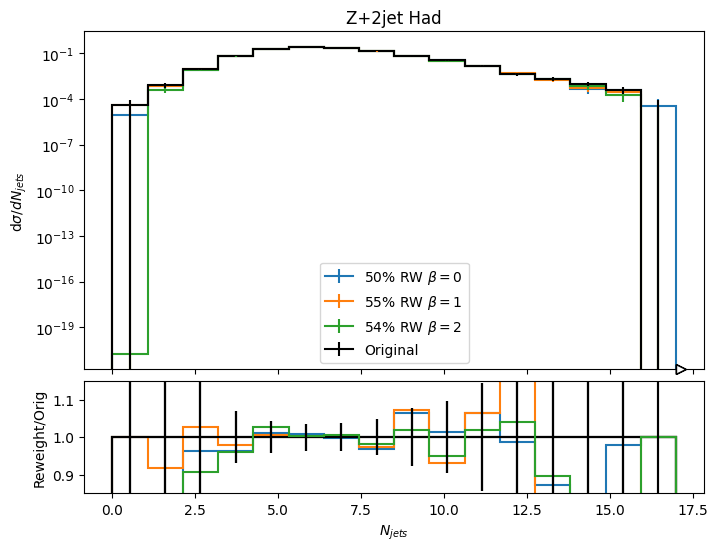

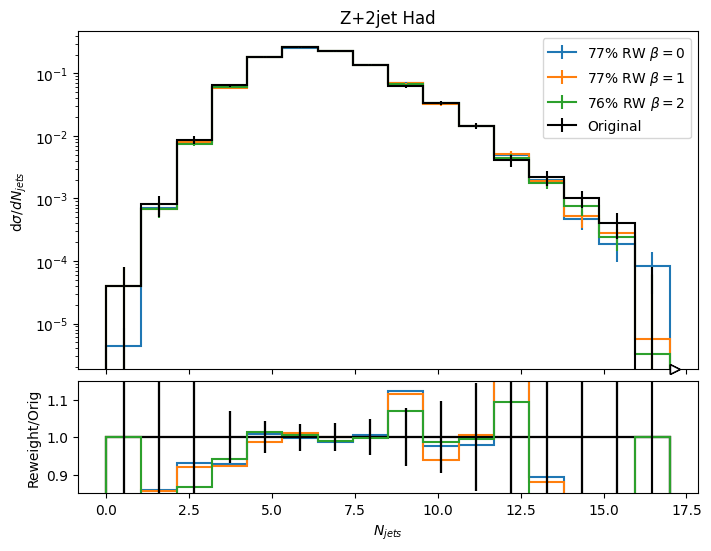

In [13]:
process_str = [r"$\beta=0$", r"$\beta=1$",r"$\beta=2$"]
print(zjet_b0_had_df["fraction"].values)
print(zjet_had_df["fraction"].values)
print(zjet_b2_had_df["fraction"].values)
fracs = [0.23, 0.26, 0.25]
dfs = [zjet_b0_had_df, zjet_had_df, zjet_b2_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronized")
fracs = [0.5, 0.55, 0.54]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Had")
fracs = [0.77, 0.77, 0.76]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Had")

[0.13 0.26 0.6  0.73 0.85 0.91 0.93 0.97]
[0.04 0.24 0.32 0.52 0.53 0.68 0.77 0.84 0.92]
[0.   0.26 0.55 0.68 0.77 0.85 0.92]


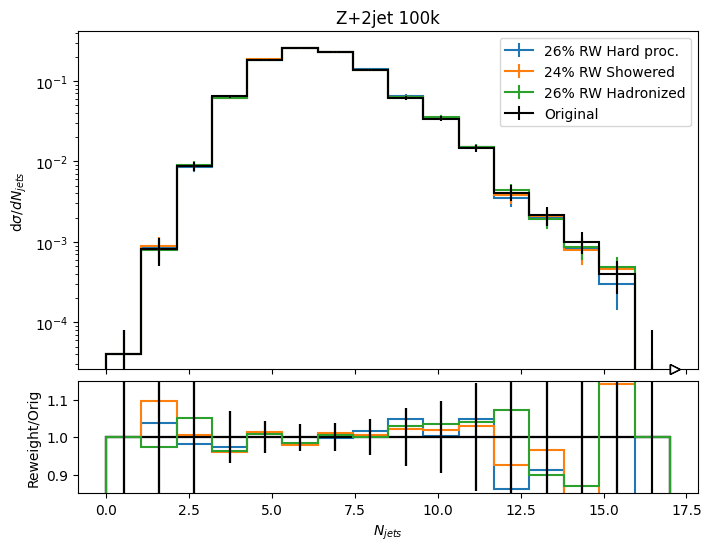

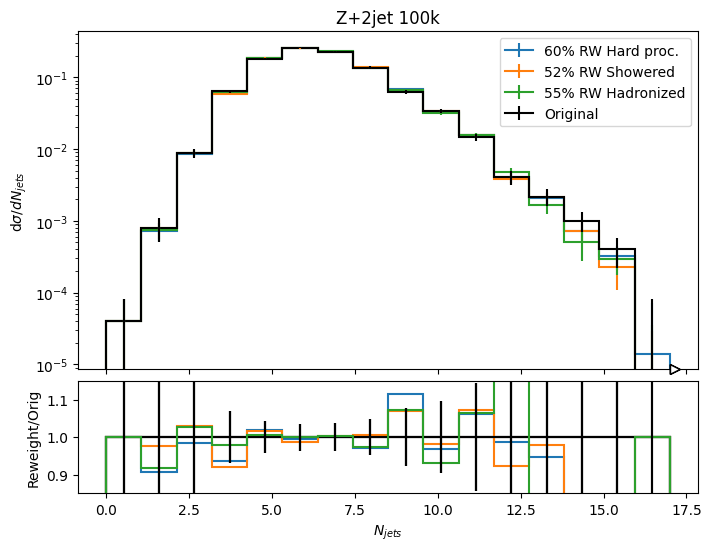

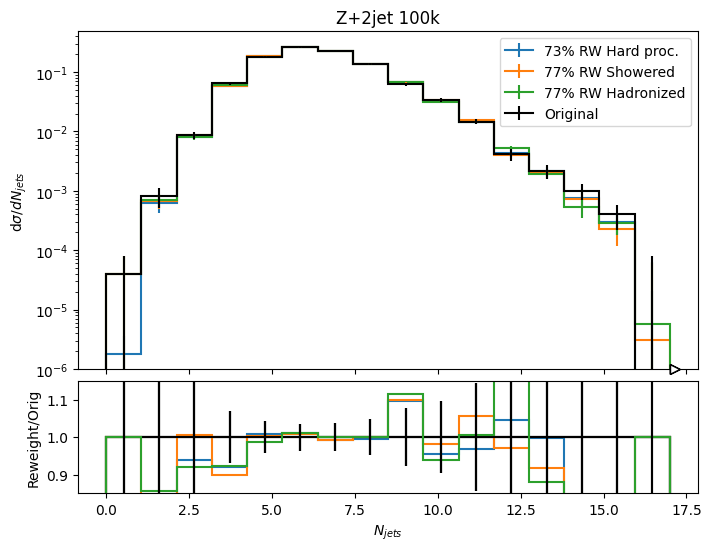

In [14]:
process_str = ["Hard proc.", "Showered", "Hadronized"]
print(zjet_hp_df["fraction"].values)
print(zjet_ps_df["fraction"].values)
print(zjet_had_df["fraction"].values)
fracs = [0.26, 0.24, 0.26]
dfs = [zjet_hp_df, zjet_ps_df, zjet_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k")
fracs = [0.6, 0.52, 0.55]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k")
fracs = [0.73, 0.77, 0.77]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k")

[0.   0.07 0.17 0.25 0.37 0.53 0.71 0.87 1.  ]
[0.   0.01 0.04 0.25 0.3  0.54 0.93 0.99]
[0.   0.   0.25 0.42 0.53 0.94 1.  ]


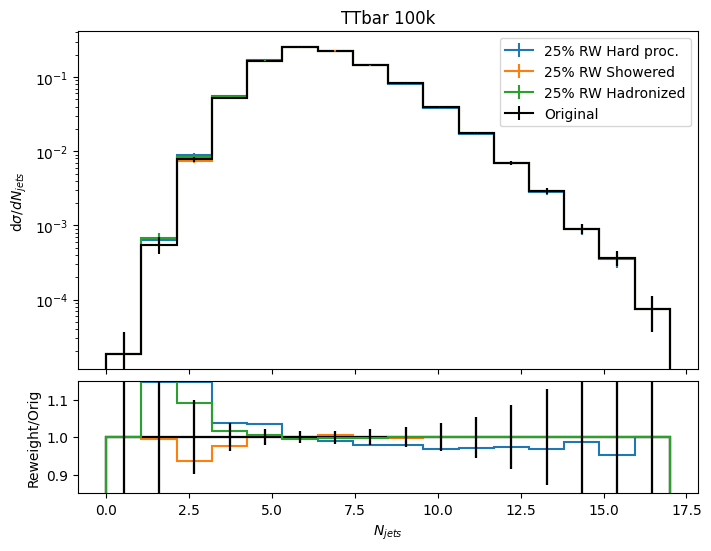

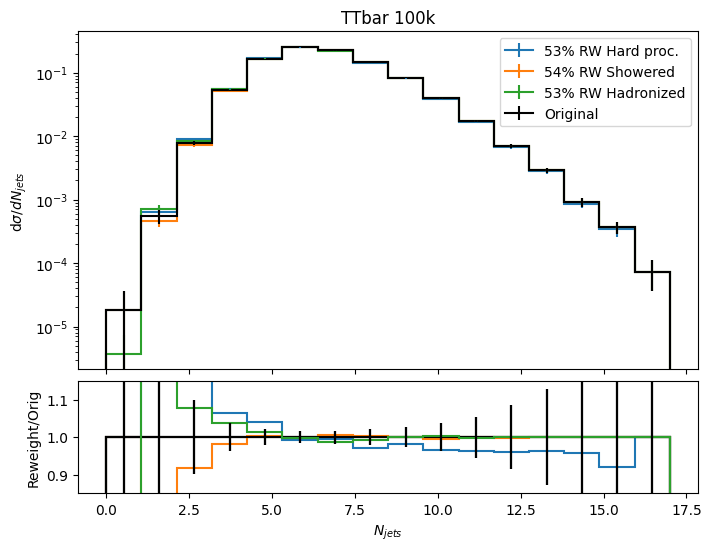

In [15]:
dictprocess_str = ["Hard proc.", "Showered", "Hadronized"]
fracs = [0.25, 0.25, 0.25]
print(ttbar_hp_df["fraction"].values)
print(ttbar_ps_df["fraction"].values)
print(ttbar_had_df["fraction"].values)
dfs = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
dictprocess_str = ["Hard proc.", "Showered", "Hadronized"]
fracs = [0.53, 0.54, 0.53]
dfs = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")

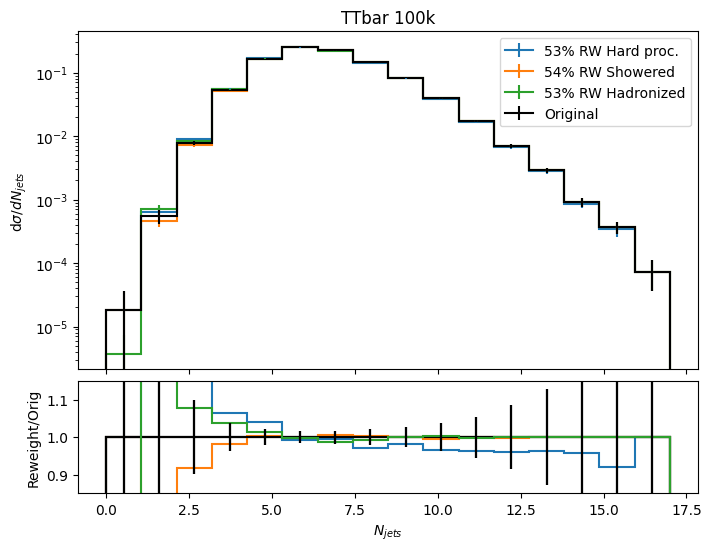

In [16]:
dictprocess_str = ["Hard proc.", "Showered", "Hadronized"]
fracs_50 = [0.53, 0.54, 0.53]
dfs = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")

/tmp/ipykernel_3896472/278719642.py:27: RuntimeWarning: invalid value encountered in sqrt
  hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black')


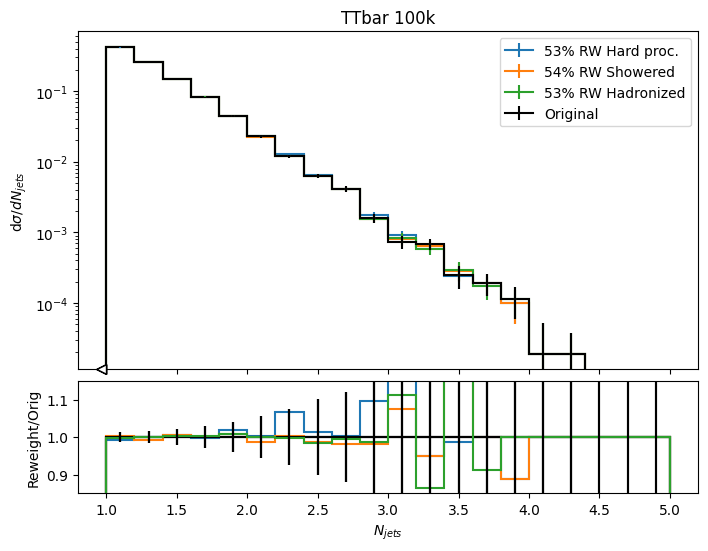

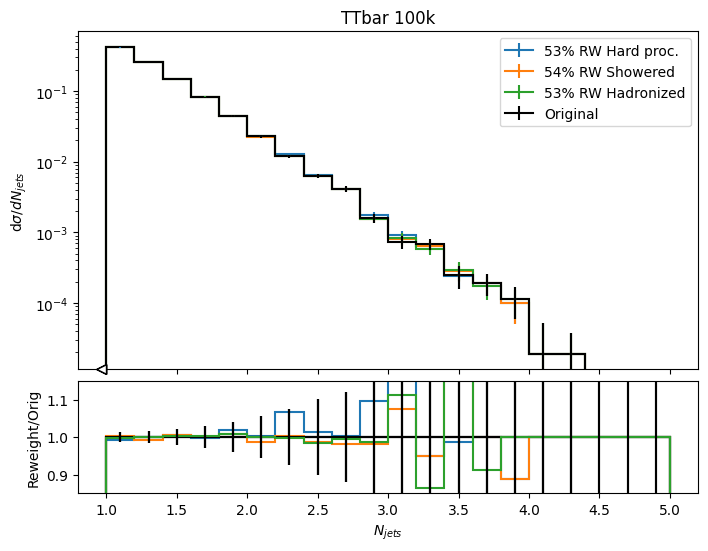

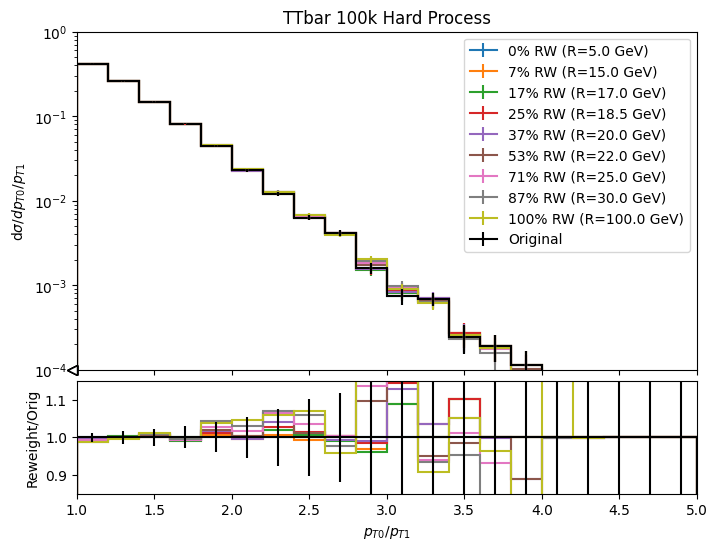

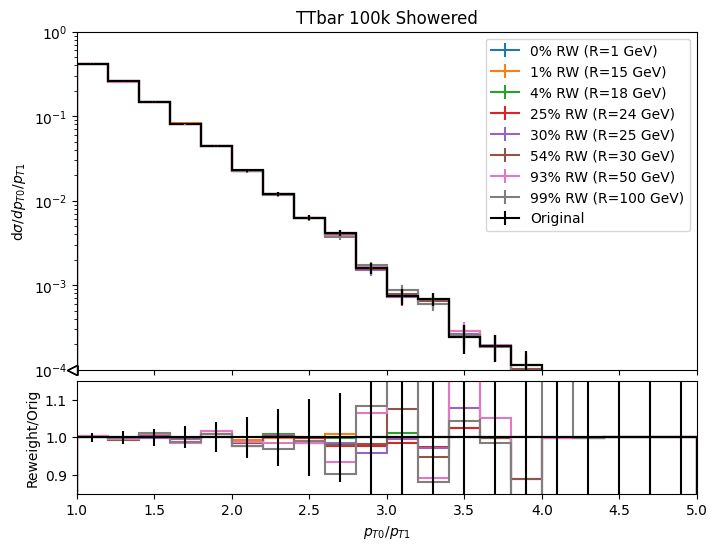

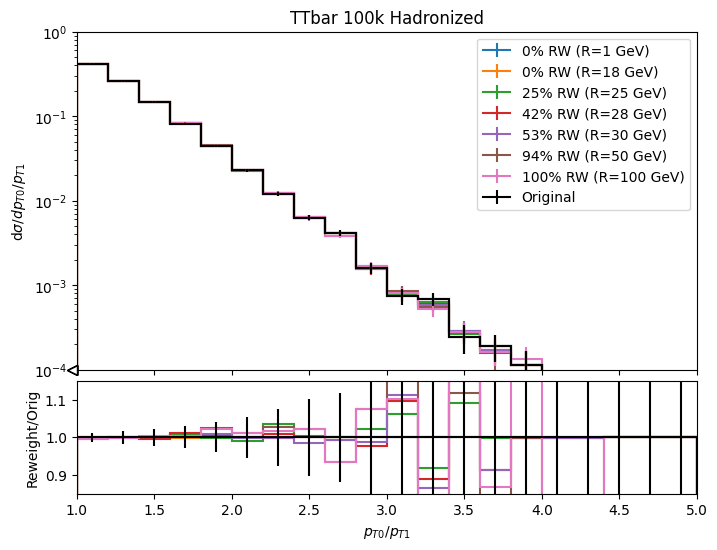

In [17]:
### plot pt ratio of leading and subleading jet
# from plotting import *
obs_str = 'p_{T0}/p_{T1}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin = 1
xmax=5
sel = (ak.num(ttbar_jets.pt, axis=1)>1)
sel_jets = ttbar_jets[sel]
obs = sel_jets.pt[:,-1]/sel_jets.pt[:,-2]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = obs_str, title = "TTbar 100k", sel=sel)
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = obs_str, title = "TTbar 100k", sel=sel)
plot_same_rw_all(obs, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Hard Process")
plot_same_rw_all(obs, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Showered")
plot_same_rw_all(obs, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Hadronized")

/tmp/ipykernel_3896472/278719642.py:27: RuntimeWarning: invalid value encountered in sqrt
  hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black')


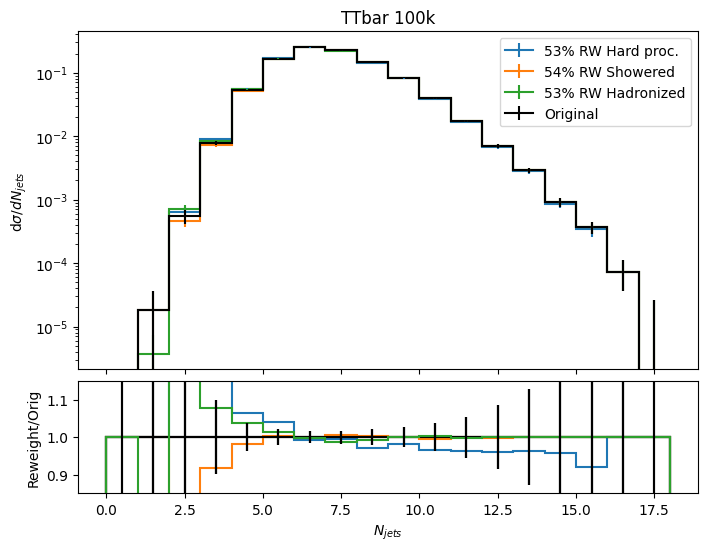

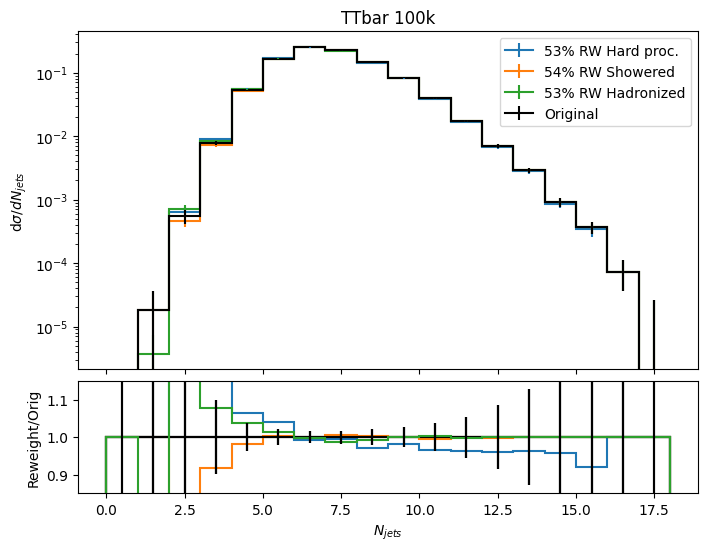

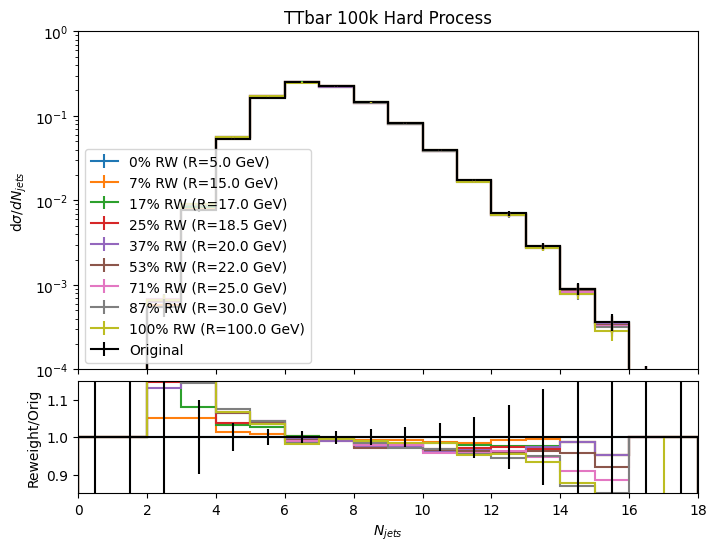

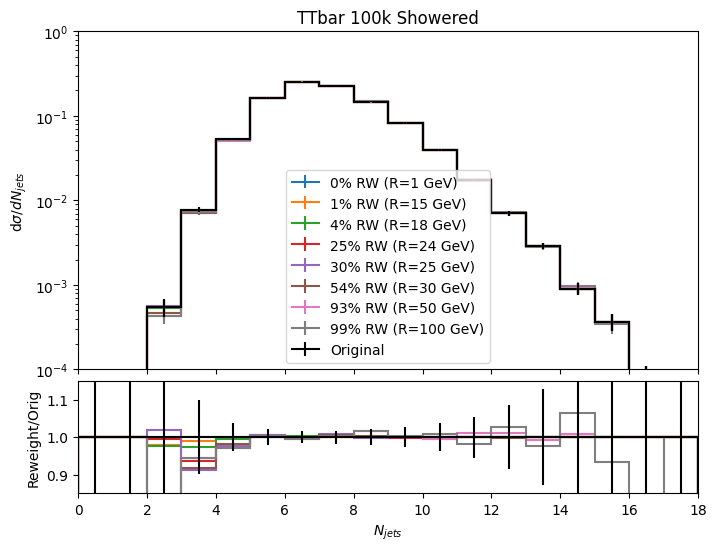

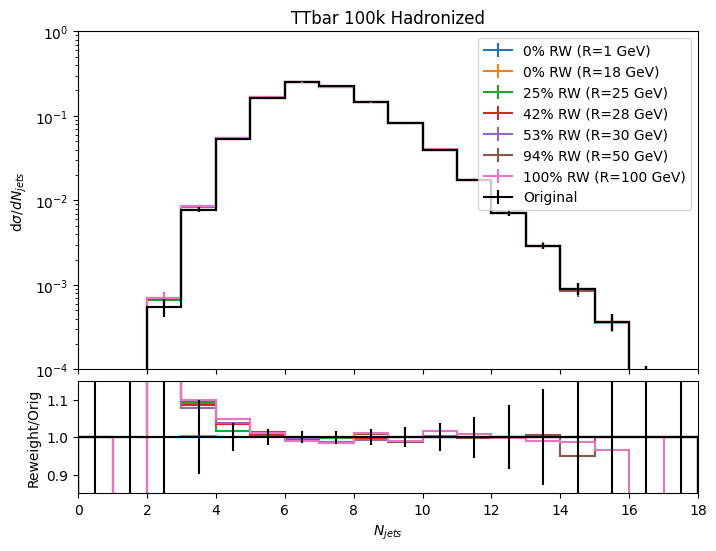

In [18]:
### plot njets
quantity = r'N_{jets}' #string for labels and stuff is the observable
numbins = 18 #number of bins
xmin=0
xmax=18
njets = ak.num(jets.pt, axis=1)
plot_diff_rw(njets, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(njets, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(njets, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(njets, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(njets, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

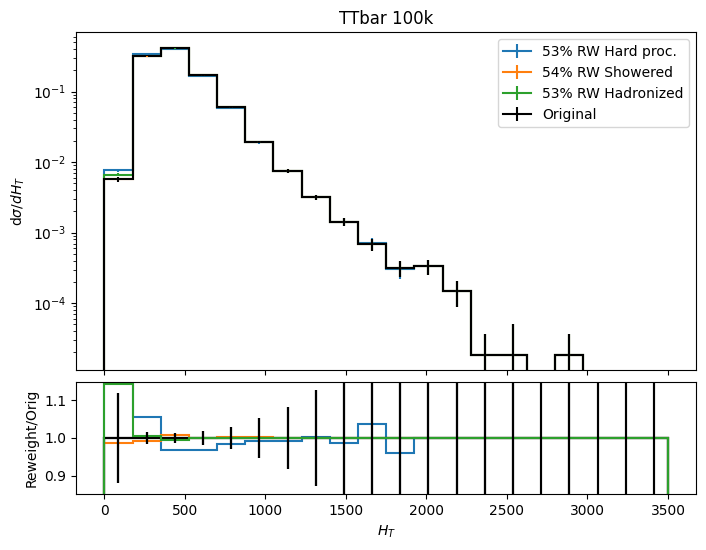

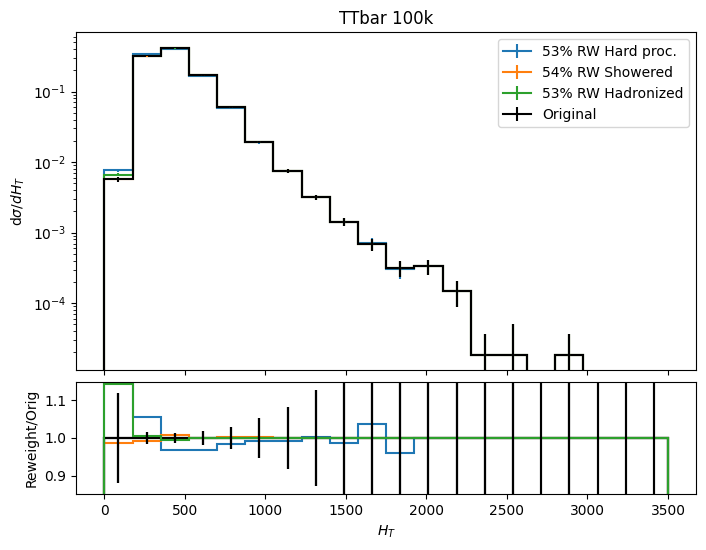

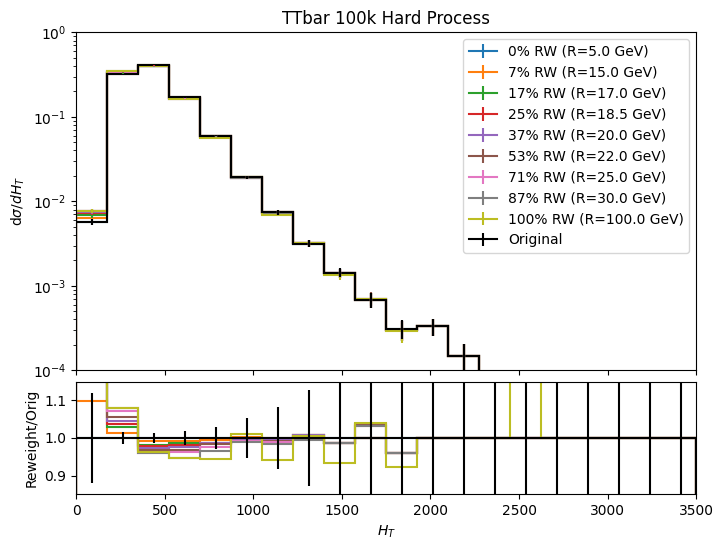

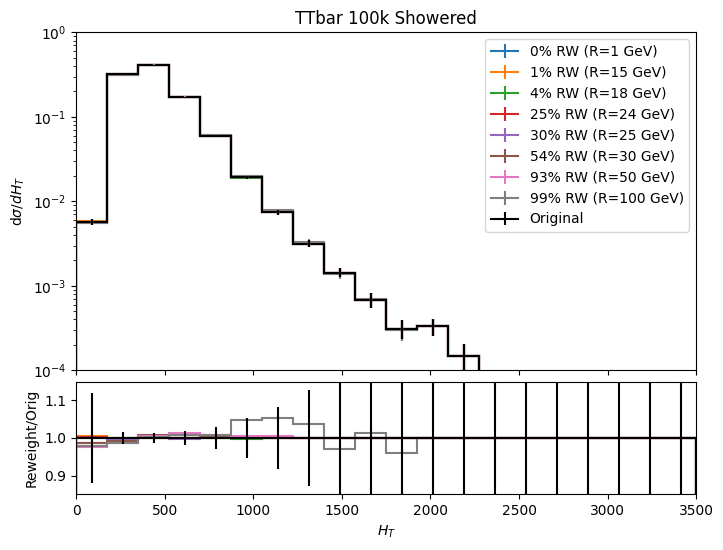

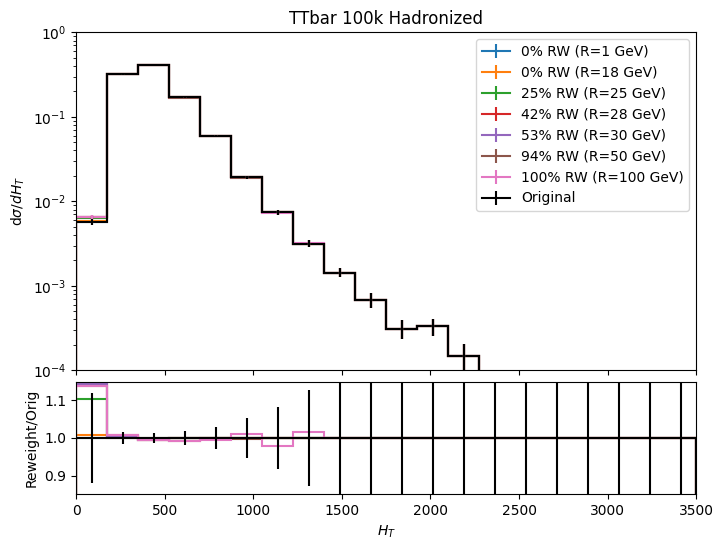

In [19]:
### plot njets
quantity = 'H_T' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin=0
xmax=3500
ht = ak.sum(ttbar_jets.pt, axis=-1)
plot_diff_rw(ht, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(ht, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(ht, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(ht, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(ht, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

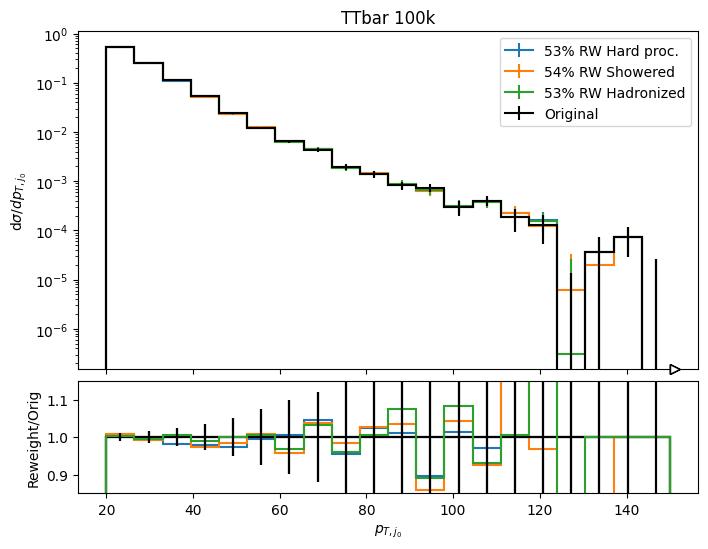

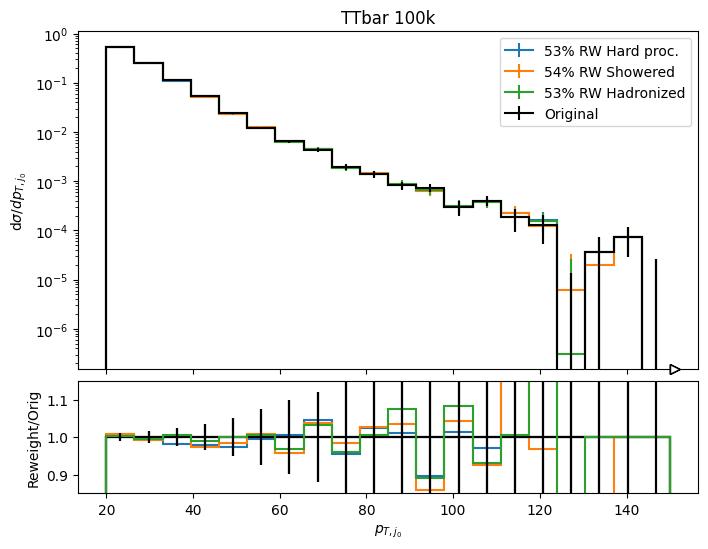

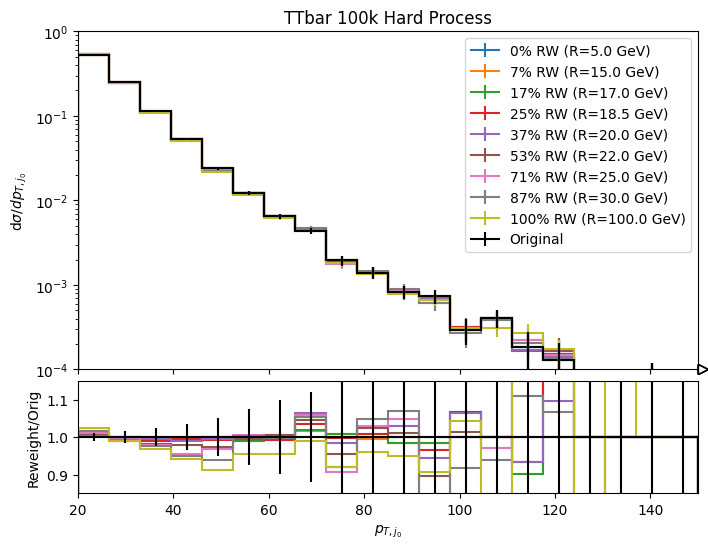

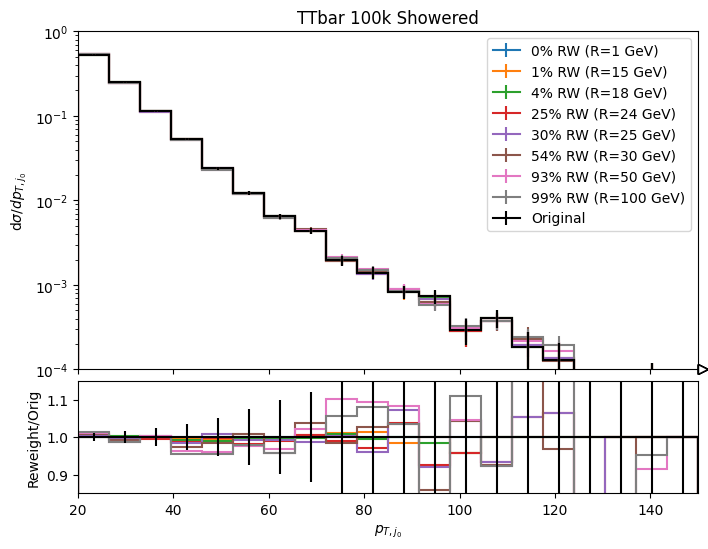

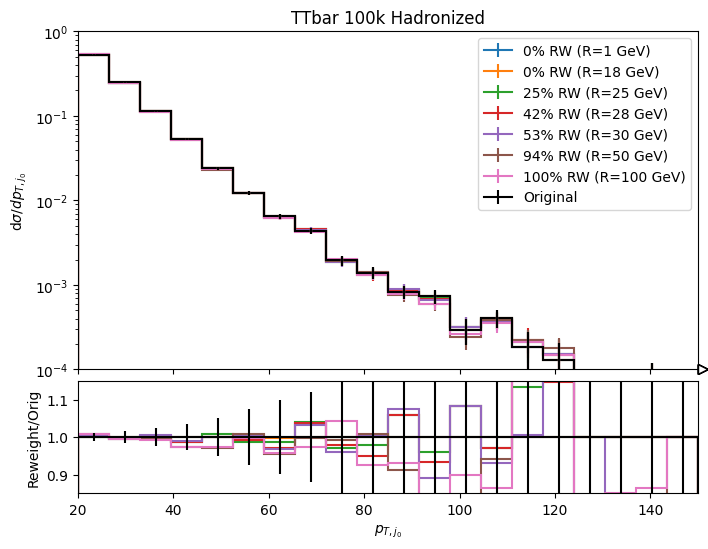

In [20]:
### plot njets
quantity = 'p_{T,j_0}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin=20
xmax=150
pt0 = ttbar_jets.pt[:,0]
plot_diff_rw(pt0, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(pt0, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(pt0, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(pt0, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(pt0, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

99999


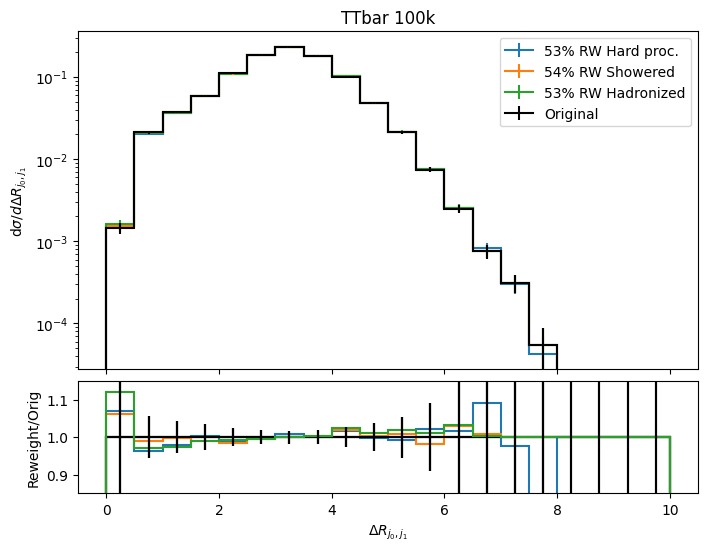

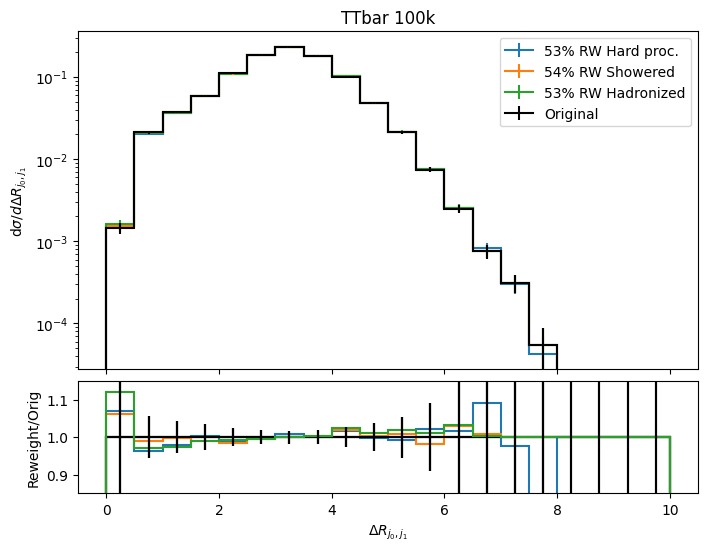

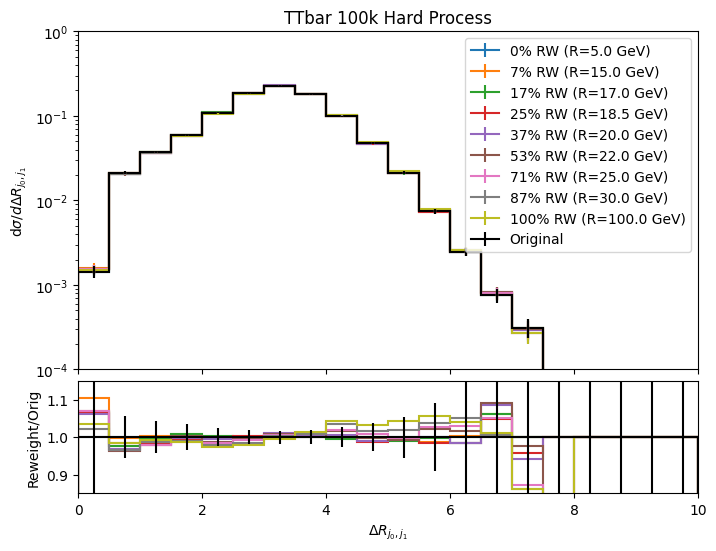

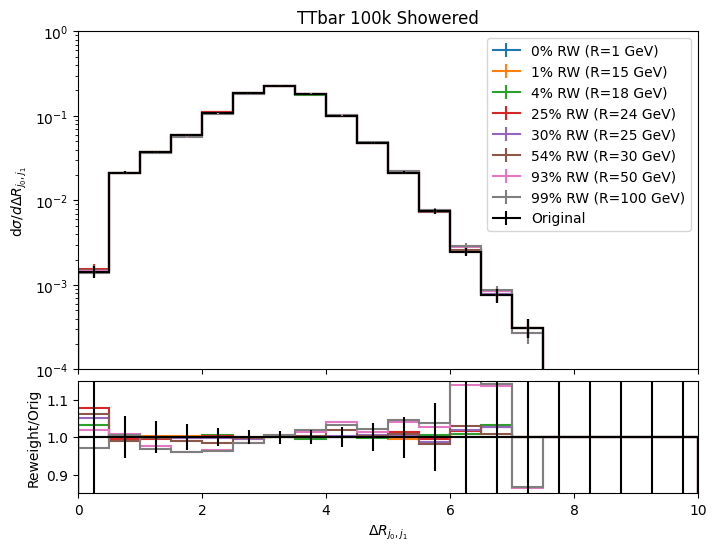

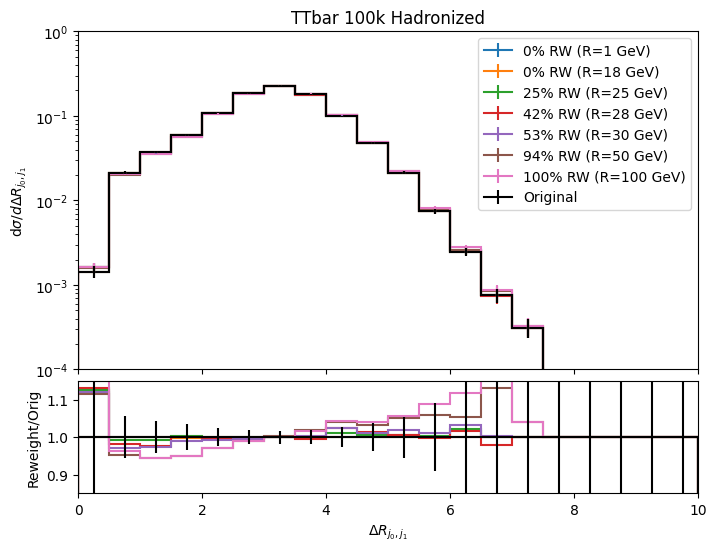

In [21]:
quantity = "\Delta R_{j_0, j_1}"
xmin = 0
xmax = 10
obs= np.sqrt((sel_jets.eta[:,-1] - sel_jets.eta[:,-2])**2 + (sel_jets.phi[:,-1] - sel_jets.phi[:,-2])**2)
print(len(obs))
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(obs, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(obs, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(obs, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")

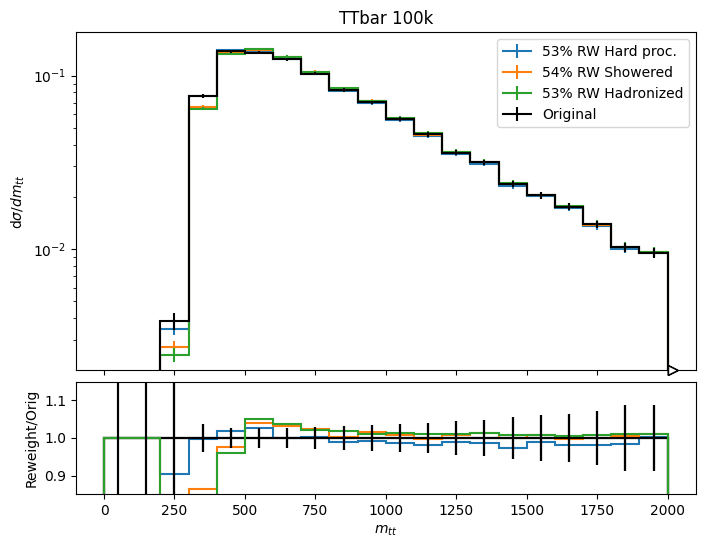

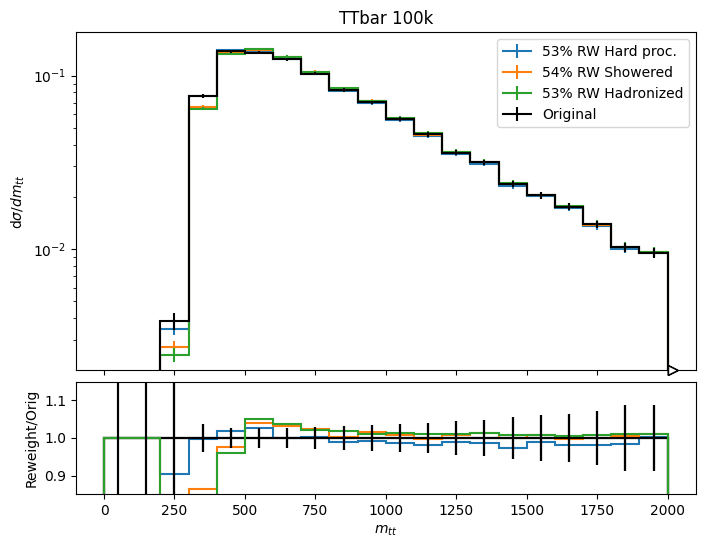

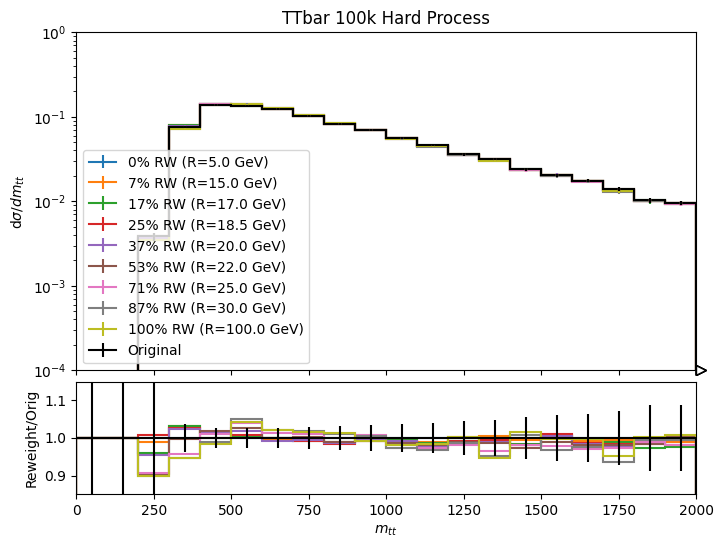

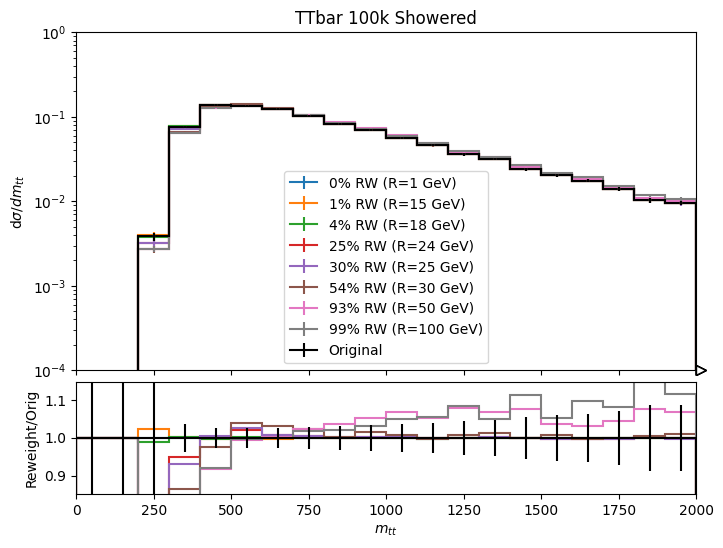

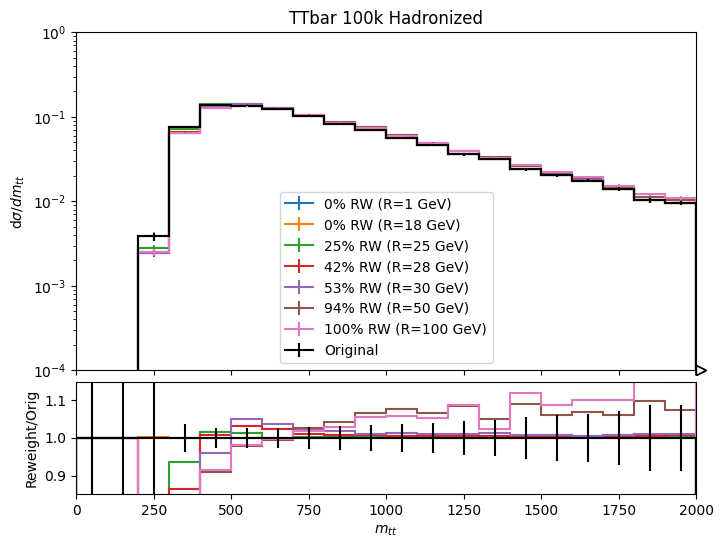

In [22]:
quantity="m_{tt}"
sel = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass
numbins = 20
xmin=0
xmax=2000
plot_diff_rw(mtt, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(mtt, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(mtt, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(mtt, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(mtt, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")

74826
74826


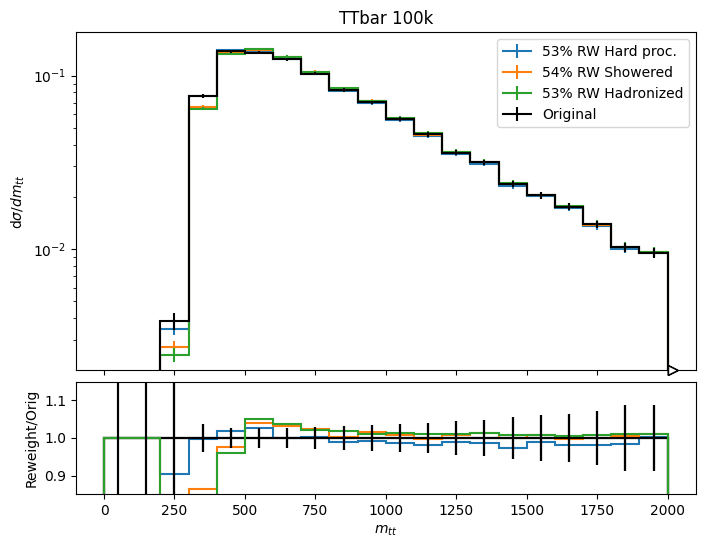

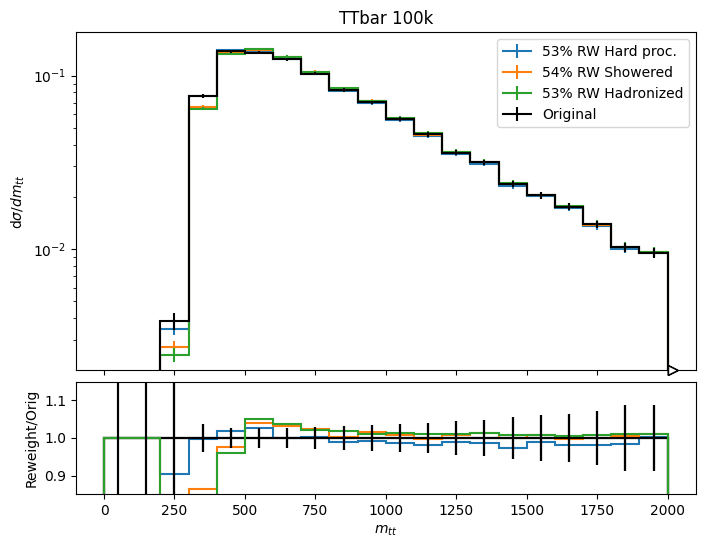

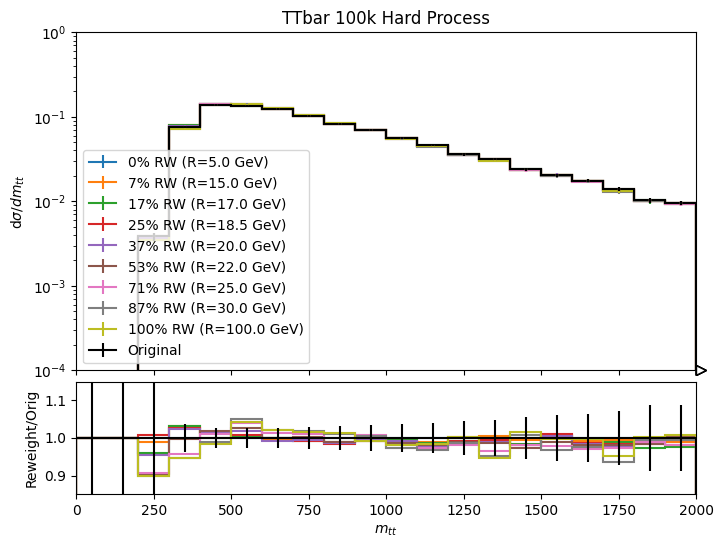

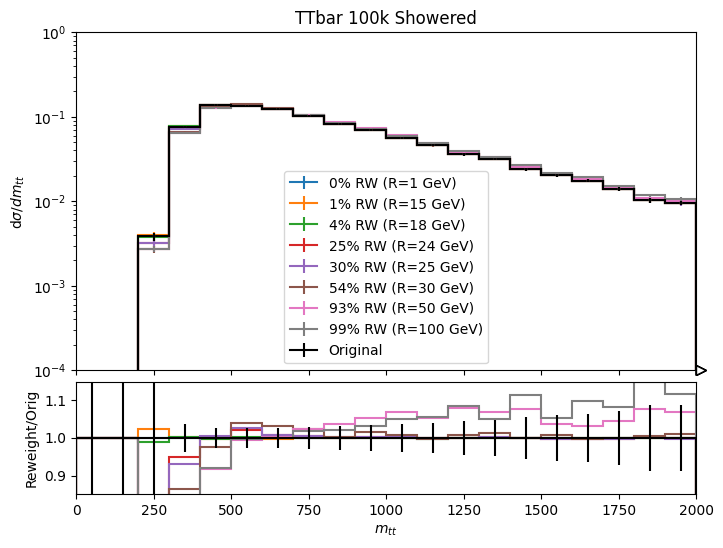

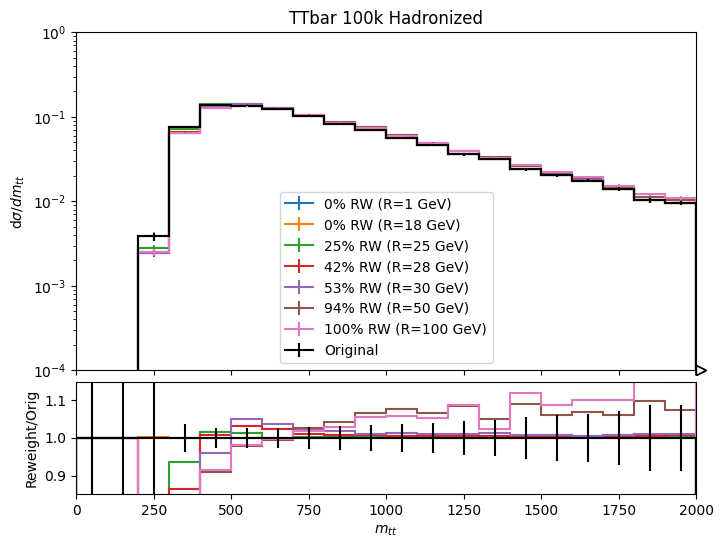

In [23]:
quantity="m_{tt}"
sel = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass
numbins = 20
xmin=0
xmax=2000
print(len(mtt))
print(np.sum(sel))
plot_diff_rw(mtt, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(mtt, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(mtt, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(mtt, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(mtt, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")